In [7]:
%pip install pandas
%pip install matplotlib
%pip install scipy


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd

#Importing Data
data = pd.read_csv("../data/player.csv")

matches = pd.read_csv("../data/matches.csv")
print(matches)


       teamId        team  matchId                            date  \
0       11283     Falcons  2396609    Results for August 22nd 2026   
1       11283     Falcons  2396604    Results for August 20th 2026   
2       11283     Falcons  2396579    Results for August 14th 2026   
3       11283     Falcons  2396563    Results for August 13th 2026   
4       11283     Falcons  2396005      Results for July 23rd 2026   
...       ...         ...      ...                             ...   
15043   13657  Blitzkrieg  2390458  Results for February 16th 2026   
15044   13657  Blitzkrieg  2390309  Results for February 13th 2026   
15045   13657  Blitzkrieg  2390177  Results for February 11th 2026   
15046   13657  Blitzkrieg  2389927   Results for February 7th 2026   
15047   13657  Blitzkrieg  2389900   Results for February 3rd 2026   

            teamA            teamB   score  \
0         Falcons           Legacy   0 - 2   
1         Falcons      The MongolZ   2 - 0   
2         Falcons    

In [10]:
#DATA CLEANING

#Dropping inactive players 
data = data.dropna()

#Age to int and removal of string
data["age"] = (data["age"].astype(str).str.replace(" years", "", regex=False).astype(int)
)

#Cleaning and retyping stats data
stats = [
    "Firepower",
    "Entrying",
    "Trading",
    "Opening",
    "Clutching",
    "Sniping",
    "Utility"
]

for col in stats:
    data[col] = pd.to_numeric(
        data[col].astype(str).str.replace("/100", "", regex=False),
        errors="coerce"
    ).astype("Int64")

#Cleaning date of matches
matches["date"] = matches["date"].str.replace("Results for ", "", regex=False)
print(matches)
matches.to_csv('../data/matches_processed.csv')



       teamId        team  matchId                date       teamA  \
0       11283     Falcons  2396609    August 22nd 2026     Falcons   
1       11283     Falcons  2396604    August 20th 2026     Falcons   
2       11283     Falcons  2396579    August 14th 2026     Falcons   
3       11283     Falcons  2396563    August 13th 2026     Falcons   
4       11283     Falcons  2396005      July 23rd 2026     Falcons   
...       ...         ...      ...                 ...         ...   
15043   13657  Blitzkrieg  2390458  February 16th 2026  Blitzkrieg   
15044   13657  Blitzkrieg  2390309  February 13th 2026  Blitzkrieg   
15045   13657  Blitzkrieg  2390177  February 11th 2026  Blitzkrieg   
15046   13657  Blitzkrieg  2389927   February 7th 2026  Blitzkrieg   
15047   13657  Blitzkrieg  2389900   February 3rd 2026  Blitzkrieg   

                 teamB   score  \
0               Legacy   0 - 2   
1          The MongolZ   2 - 0   
2             Astralis   2 - 0   
3                  K27 

In [2]:
import pandas as pd
team_strength = pd.read_csv("../outputs/team_strength.csv")
team_strength.sort_values("strength", ascending=False, inplace=True)
print(team_strength)

      tier           team  strength  strength_gap  matches  wins  losses  \
0        1       Vitality   2289.83         67.58      110    89      21   
1        1           MOUZ   2222.25         19.27      107    70      37   
2        1         Spirit   2202.98         63.26      102    77      25   
3        1        Falcons   2139.72         57.33      102    70      32   
4        1  Natus Vincere   2082.39          5.25      101    62      39   
...    ...            ...       ...           ...      ...   ...     ...   
1218     2      CAPIVARAS   1020.69          0.93        6     0       6   
1219     2       Lotus fe   1019.76          7.21        6     0       6   
1220     2   thekillaz fe   1012.55         12.64        6     0       6   
1221     2        Pigeons    999.91         19.68       13     0      13   
1222     2     Time Waves    980.23          0.00       13     0      13   

      win_rate  
0        0.809  
1        0.654  
2        0.755  
3        0.686  
4 

In [8]:
import pandas as pd
#MERGING OF BOTH DATA FRAMES
teamdata = pd.read_csv("../data/teams.csv")

combined = pd.merge(data, teamdata, on="team")
print(combined)

    playername  age         team  Clutching  Entrying  Firepower  Opening  \
0          910   24  The MongolZ         44        26         88       79   
1         acoR   29        Sashi         73        36         69       76   
2        adamb   21           OG         26        66         74       50   
3        adamS   25       Sangal         57        72         96       89   
4         afro   27   Luminosity         64         2         45       43   
..         ...  ...          ...        ...       ...        ...      ...   
283       Zero   20        TYLOO         40        61         51       39   
284     zont1x   21       Spirit         34        53         26       22   
285      zorte   28      BetBoom         80        17         29       54   
286      zweih   18   PARIVISION         74        38         38       43   
287      ZywOo   25     Vitality         87        42         98       68   

     Rating 3.0  Sniping  Trading  Utility  hltvPoints  ranking  
0        

In [28]:
print((combined["Firepower"] > 95).sum())
#print((data["Utility"] > 90).sum())
#print((data["Clutching"] > 90).sum())
print(len(data))

#print(data[data["Clutching"] > 90])
print(combined.loc[
    (combined["Firepower"] > 90) &
    (combined["ranking"] < 10), ["playername", "Firepower", "team","ranking"]])
print(combined.loc[
    (combined["Sniping"] > 80) &
    (combined["ranking"] < 10), ["playername", "Firepower", "Sniping", "team","ranking"]])
print(combined.loc[
    (combined["Trading"] > 80) &
    (combined["ranking"] < 10), ["playername", "Firepower", "Trading","team","ranking"]])

print(combined[combined["team"] == "M80"])

9
352
    playername  Firepower      team  ranking
61        donk        100    Spirit        2
107   Jimpphat         92    Aurora        8
143     m0NESY         91   Falcons        1
287      ZywOo         98  Vitality        4
    playername  Firepower  Sniping           team  ranking
143     m0NESY         91       94        Falcons        1
160     meyern         18       92             9z        9
169    molodoy         86       93          FURIA        3
228      sh1ro         83       94         Spirit        2
261     torzsi         72       93           MOUZ        5
271  w0nderful         59       93  Natus Vincere        6
274      woxic         63       94         Aurora        8
287      ZywOo         98       87       Vitality        4
    playername  Firepower  Trading           team  ranking
271  w0nderful         59       89  Natus Vincere        6
    playername  age team  Clutching  Entrying  Firepower  Opening  Rating 3.0  \
102        JBa   22  M80         82    

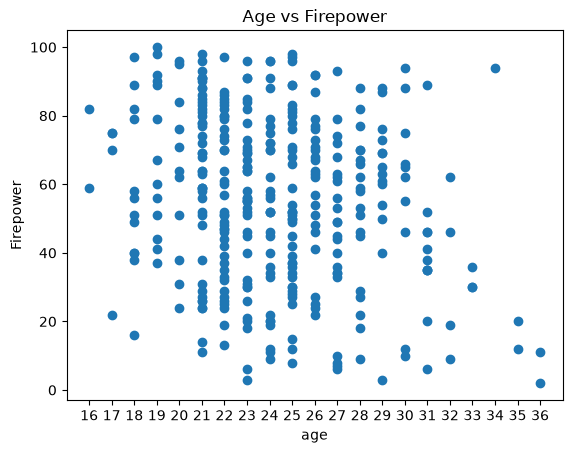

In [22]:
import matplotlib.pyplot as plt
plt.scatter(data["age"], data["Firepower"])

plt.xlabel("age")
plt.ylabel("Firepower")
plt.title("Age vs Firepower")
plt.xticks(range(16,37,1))

plt.show()

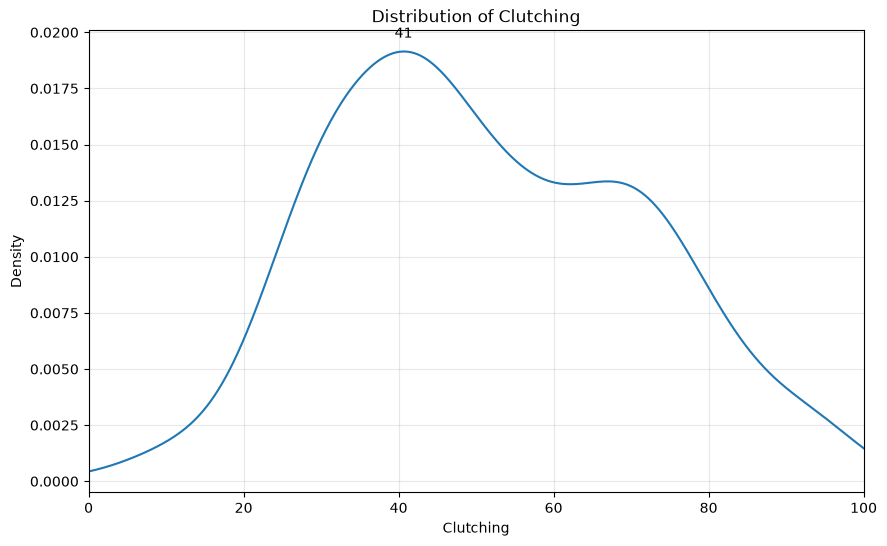

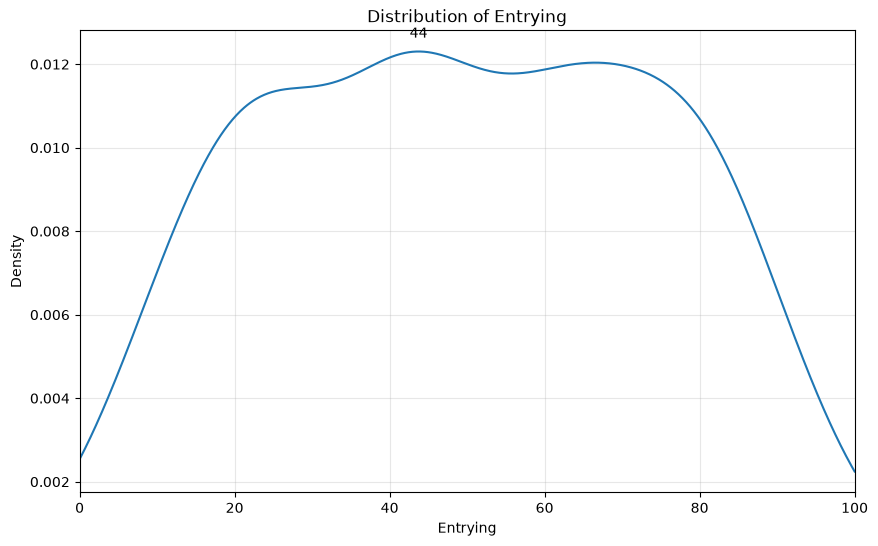

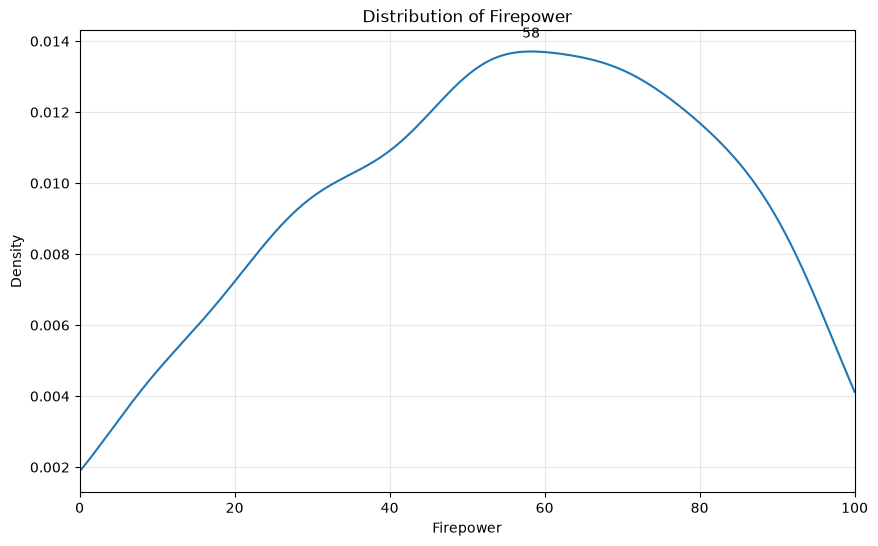

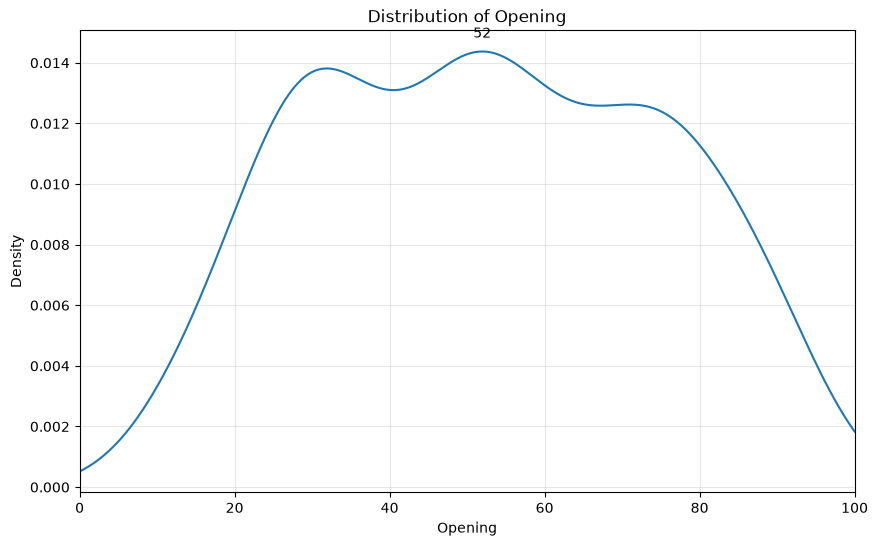

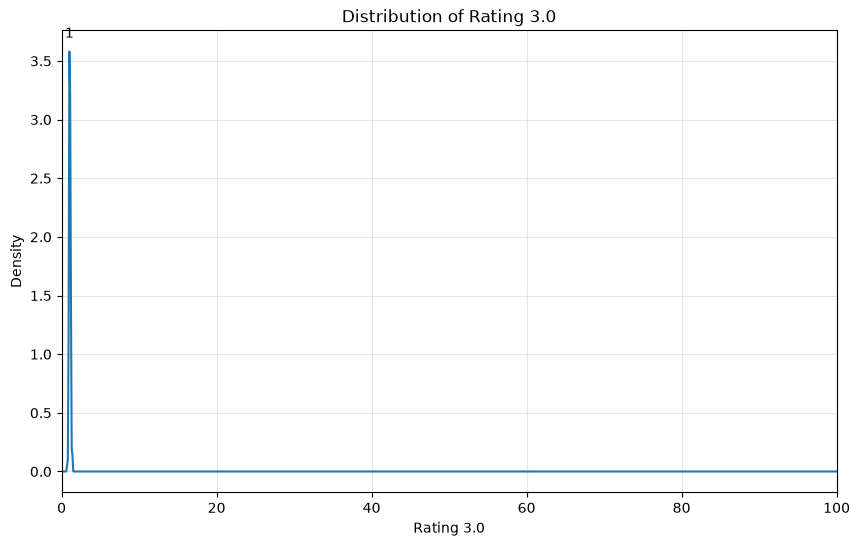

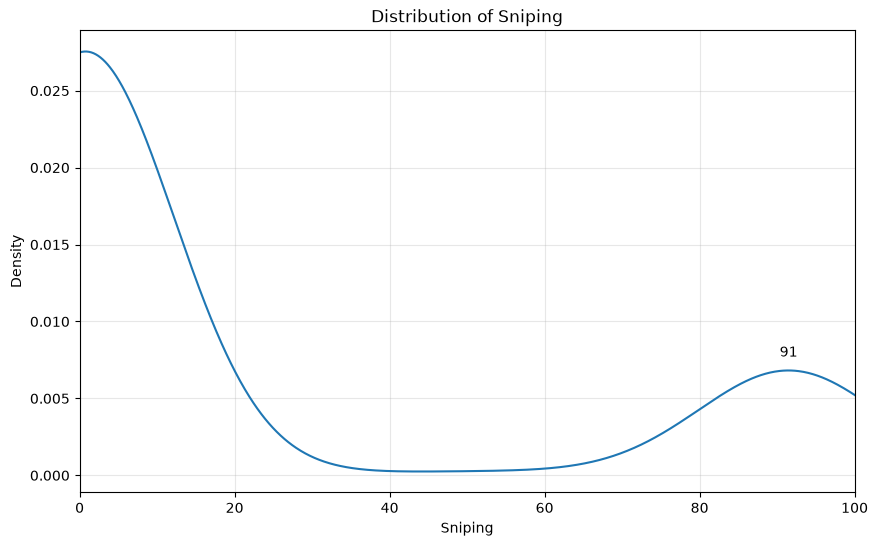

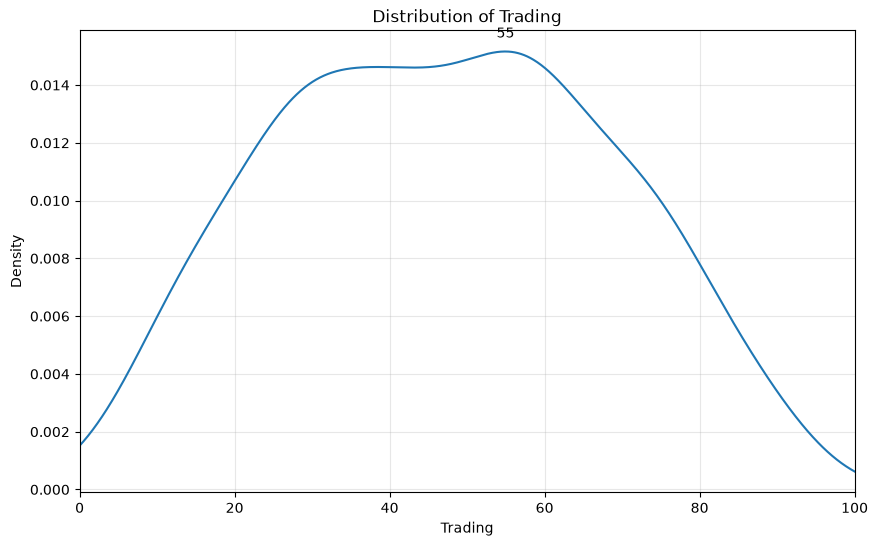

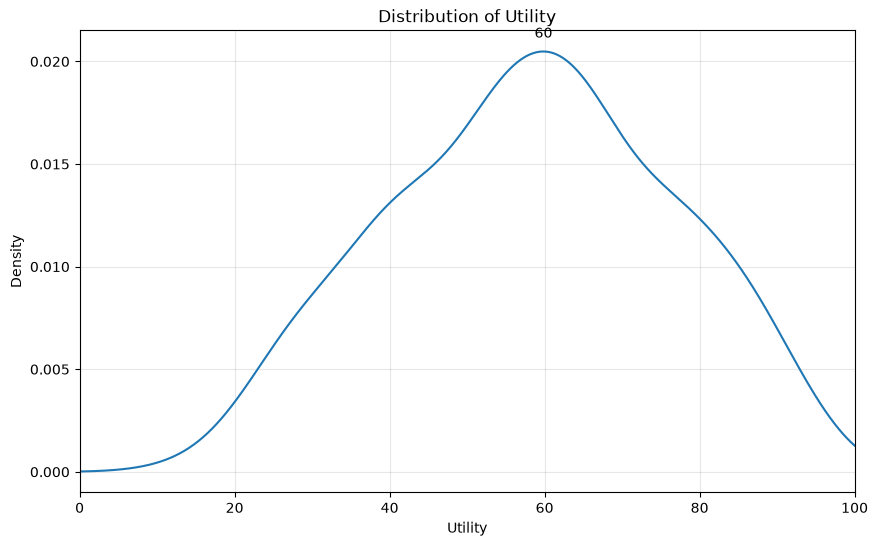

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

# Columns that aren't stats
exclude = ["playername", "age", "team"]

# Automatically get stat columns
stats = [col for col in data.columns if col not in exclude]

for col in stats:

    # Remove missing values
    values = data[col].dropna().to_numpy()

    # Create KDE
    kde = gaussian_kde(values)

    # Create x values from 0 to 100
    x = np.linspace(0, 100, 1000)

    # Calculate density
    y = kde(x)

    # Find peaks in the density curve
    peaks, properties = find_peaks(
        y,
        prominence=0.001
    )

    # Create chart
    plt.figure(figsize=(10, 6))

    plt.plot(x, y)

    # Label peaks
    for peak in peaks:
        plt.annotate(
            f"{x[peak]:.0f}",
            (x[peak], y[peak]),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center"
        )

    # Formatting
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.xlim(0, 100)
    plt.grid(alpha=0.3)

    plt.show()